In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

In [3]:
print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


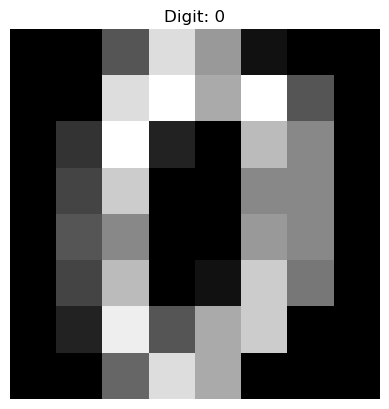

In [4]:
plt.imshow(digits.images[0], cmap="gray")
plt.title("Digit: " + str(y[0]))
plt.axis("off")
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [7]:
train_predictions = model.predict(X_train)

test_predictions = model.predict(X_test)

In [8]:
train_accuracy = accuracy_score(y_train, train_predictions)

test_accuracy = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", train_accuracy)

print("Test Accuracy:", test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.975


In [9]:
cm = confusion_matrix(y_test, test_predictions)

print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


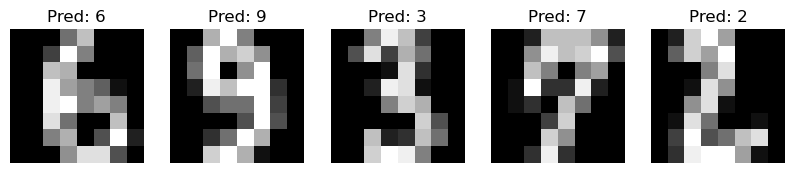

In [10]:
correct = []

for i in range(len(y_test)):
    if y_test[i] == test_predictions[i]:
        correct.append(i)

plt.figure(figsize=(10,2))

for i in range(5):
    index = correct[i]

    plt.subplot(1,5,i+1)

    plt.imshow(X_test[index].reshape(8,8), cmap="gray")

    plt.title("Pred: " + str(test_predictions[index]))

    plt.axis("off")

plt.show()

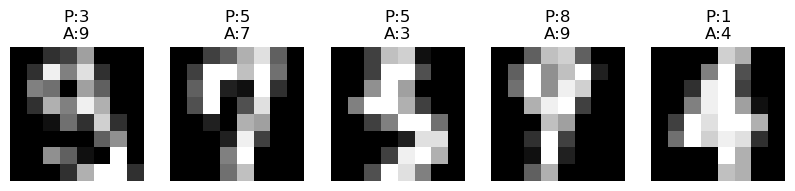

In [11]:
wrong = []

for i in range(len(y_test)):
    if y_test[i] != test_predictions[i]:
        wrong.append(i)

plt.figure(figsize=(10,2))

for i in range(min(5, len(wrong))):
    index = wrong[i]

    plt.subplot(1,5,i+1)

    plt.imshow(X_test[index].reshape(8,8), cmap="gray")

    plt.title(
        "P:" + str(test_predictions[index]) +
        "\nA:" + str(y_test[index])
    )

    plt.axis("off")

plt.show()